In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("/content/cleaned_deliveries.csv")


In [ ]:
df.head()


,match_id,inning,over_ball,over,ball,batting_team,bowling_team,batter,non_striker,bowler,runs_off_bat,extras,iswide,isnoball,dismissal_kind,player_dismissed,date,is_wicket
0,335982,1,0.1,0,1,Kolkata Knight Riders,RCB,SC Ganguly,BB McCullum,P Kumar,0,1,0,0,Not Out,NaN,2008-04-18,0
1,335982,1,0.2,0,2,Kolkata Knight Riders,RCB,BB McCullum,SC Ganguly,P Kumar,0,0,0,0,Not Out,NaN,2008-04-18,0
2,335982,1,0.3,0,3,Kolkata Knight Riders,RCB,BB McCullum,SC Ganguly,P Kumar,0,1,1,0,Not Out,NaN,2008-04-18,0
3,335982,1,0.4,0,4,Kolkata Knight Riders,RCB,BB McCullum,SC Ganguly,P Kumar,0,0,0,0,Not Out,NaN,2008-04-18,0
4,335982,1,0.5,0,5,Kolkata Knight Riders,RCB,BB McCullum,SC Ganguly,P Kumar,0,0,0,0,Not Out,NaN,2008-04-18,0


In [ ]:
df.shape


(260917, 18)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260917 entries, 0 to 260916
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   match_id          260917 non-null  int64  
 1   inning            260917 non-null  int64  
 2   over_ball         260917 non-null  float64
 3   over              260917 non-null  int64  
 4   ball              260917 non-null  int64  
 5   batting_team      260917 non-null  object 
 6   bowling_team      260917 non-null  object 
 7   batter            260917 non-null  object 
 8   non_striker       260917 non-null  object 
 9   bowler            260917 non-null  object 
 10  runs_off_bat      260917 non-null  int64  
 11  extras            260917 non-null  int64  
 12  iswide            260917 non-null  int64  
 13  isnoball          260917 non-null  int64  
 14  dismissal_kind    260917 non-null  object 
 15  player_dismissed  12950 non-null   object 
 16  date              26

In [ ]:
df.describe()


,match_id,inning,over_ball,over,ball,runs_off_bat,extras,iswide,isnoball,is_wicket
count,2.609170e+05,260917.000000,260917.000000,260917.000000,260917.000000,260917.000000,260917.000000,260917.000000,260917.000000,260917.000000
mean,9.070647e+05,1.483533,9.560047,9.197707,3.623482,1.265008,0.067807,0.038579,0.004323,0.049633
std,3.679897e+05,0.502643,5.686096,5.683465,1.813839,1.639305,0.343267,0.254124,0.069688,0.217185
min,3.359820e+05,1.000000,0.100000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.500000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.400000,9.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.254066e+06,2.000000,14.400000,14.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.426312e+06,6.000000,19.900000,19.000000,11.000000,6.000000,7.000000,5.000000,5.000000,1.000000


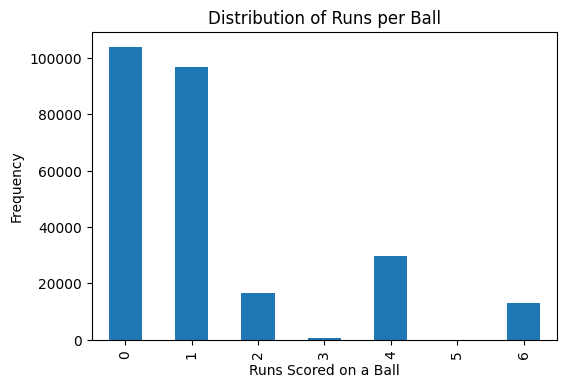

In [ ]:
plt.figure(figsize=(6,4))
df["runs_off_bat"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Runs Scored on a Ball")
plt.ylabel("Frequency")
plt.title("Distribution of Runs per Ball")
plt.show()


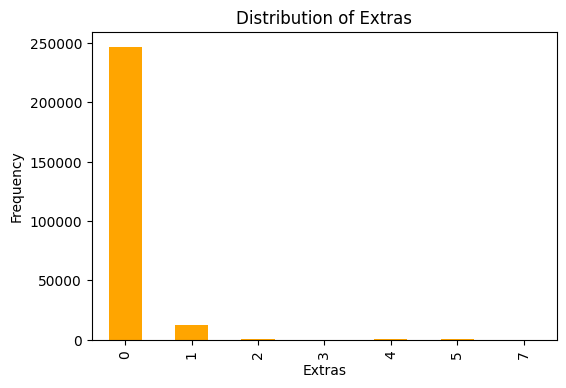

In [ ]:
plt.figure(figsize=(6,4))
df["extras"].value_counts().sort_index().plot(kind="bar", color="orange")
plt.xlabel("Extras")
plt.ylabel("Frequency")
plt.title("Distribution of Extras")
plt.show()


In [ ]:
df["is_wicket"].value_counts()


,count
is_wicket,
0,247967
1,12950


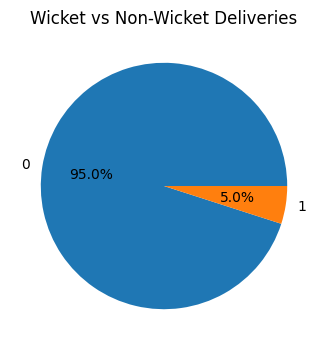

In [ ]:
plt.figure(figsize=(4,4))
df["is_wicket"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Wicket vs Non-Wicket Deliveries")
plt.ylabel("")
plt.show()


In [ ]:
runs_per_over = df.groupby("over")["runs_off_bat"].mean()


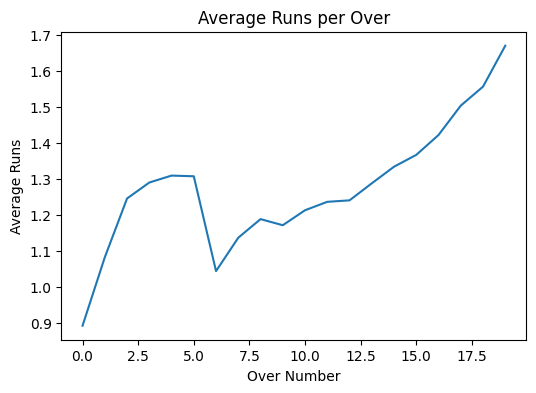

In [ ]:
plt.figure(figsize=(6,4))
runs_per_over.plot()
plt.xlabel("Over Number")
plt.ylabel("Average Runs")
plt.title("Average Runs per Over")
plt.show()


In [ ]:
top_batsmen = df.groupby("batter")["runs_off_bat"].sum().sort_values(ascending=False).head(10)


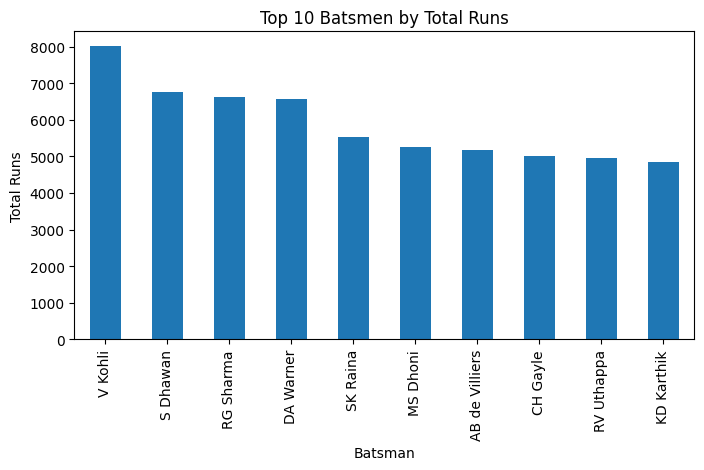

In [ ]:
plt.figure(figsize=(8,4))
top_batsmen.plot(kind="bar")
plt.xlabel("Batsman")
plt.ylabel("Total Runs")
plt.title("Top 10 Batsmen by Total Runs")
plt.show()


In [ ]:
top_bowlers = df[df["is_wicket"] == 1]["bowler"].value_counts().head(10)


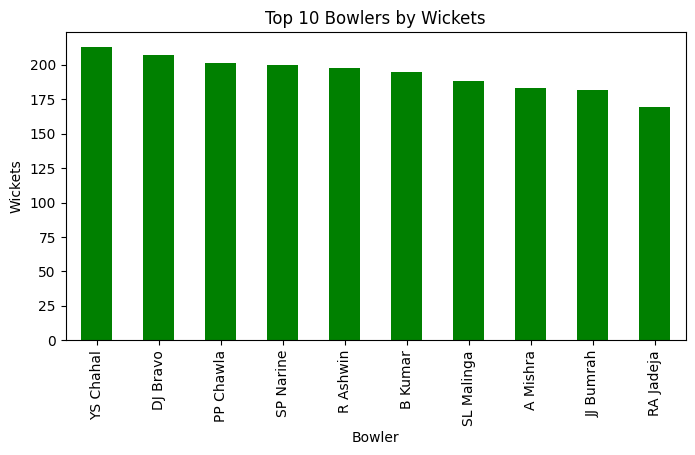

In [ ]:
plt.figure(figsize=(8,4))
top_bowlers.plot(kind="bar", color="green")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.title("Top 10 Bowlers by Wickets")
plt.show()


In [ ]:
team_runs = df.groupby("batting_team")["runs_off_bat"].sum().sort_values(ascending=False)


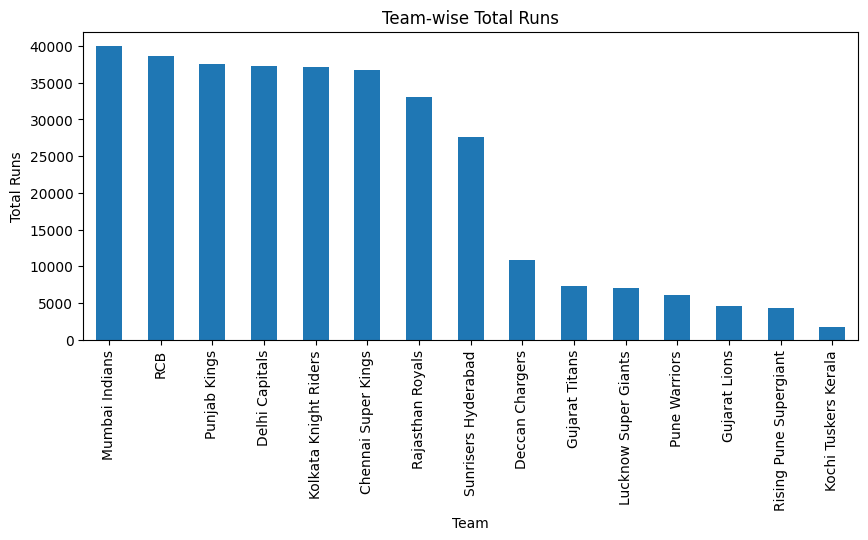

In [ ]:
plt.figure(figsize=(10,4))
team_runs.plot(kind="bar")
plt.xlabel("Team")
plt.ylabel("Total Runs")
plt.title("Team-wise Total Runs")
plt.show()


In [ ]:
numeric_cols = ["runs_off_bat", "extras", "iswide", "isnoball", "is_wicket"]


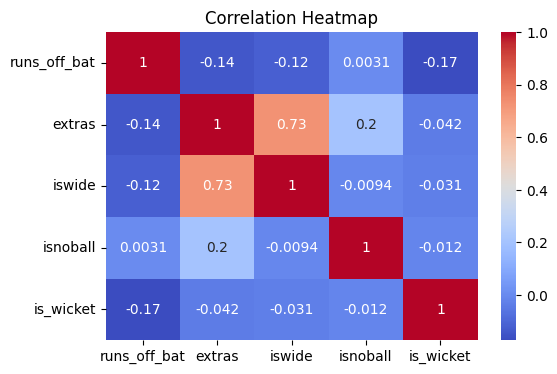

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


### Key EDA Insights

1. Most balls result in low runs (0-1).
2. Wickets are relatively rare compared to total deliveries.
3. Powerplay and death overs show higher scoring trends.
4. Batting performance varies significantly across teams.
5. Recent form is a strong indicator of player performance.


In [32]:
print("EDA completed successfully!")


EDA completed successfully!
